In [1]:
using DifferentialEquations
using Plots
using LaTeXStrings

### RL circuit

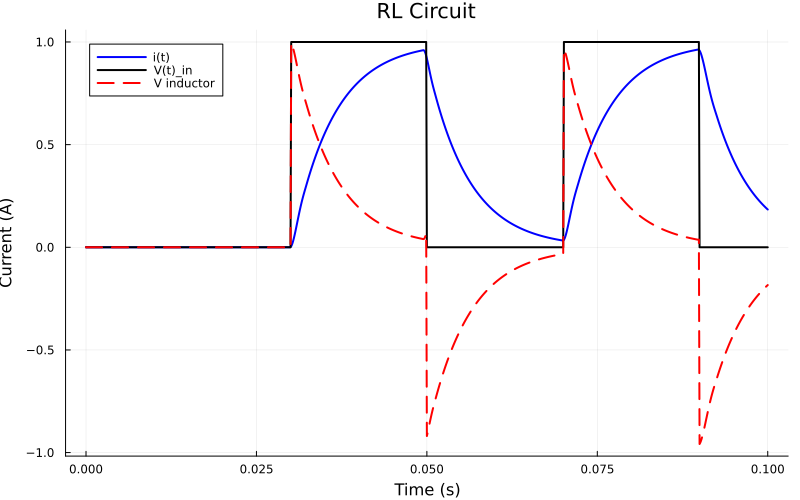

In [7]:
# Define RLC parameters
# Parameters
R = 1000   # Ohms
L = 6   # Henries
C = 1e-6   # Farads
V0 = 12#220.0      # Voltage amplitude (Volts)
ω0=30#1/sqrt(L*C)

CC=(R/2)*sqrt(C/L)
ω = 2π * 100.0   # Driving frequency (radians/s) – try 1Hz

# Voltage source: sinusoidal driving force
#V(t) = -V0*ω *cos.(ω * t)
function V(t)
    if t<0.03
        return 0
    elseif 0.03<t<0.05
        return V0
    elseif 0.05<t<0.07
        return 0
    elseif 0.07<t<0.09
        return V0
    else
        return 0
    end
end


# Define the system of ODEs
function rlc(u, p, t)
    i=u
    return (1/L)*(V(t)-R*i)
end

# Initial conditions: q(0) = 0, i(0) = 0
u0 = 0.0
tspan = (0.0,0.1)

# Define and solve the problem
prob = ODEProblem(rlc, u0, tspan)
sol = solve(prob, Tsit5(), saveat=0.0001)
# Plot the results

i_vals = [u for u in sol.u]            # or Array(sol)
t=sol.t
# compute di/dt by evaluating f at the solution points
di_dt = [ rlc(i, nothing, tt) for (i,tt) in zip(i_vals, t) ]

plot(sol.t, sol[1,:]/(V0/R), label="i(t)", lw=2,color="blue",size=(800,500),title="RL Circuit",xlabel="Time (s)",ylabel="Current (A)")
plot!(sol.t, V.(sol.t)./V0, label="V(t)_in", lw=2,color="black")
plot!(sol.t, L*di_dt/V0, label="V inductor", lw=2,color="red",linestyle=:dash)



$$V_{in}=iR+L\frac{di}{dt}$$

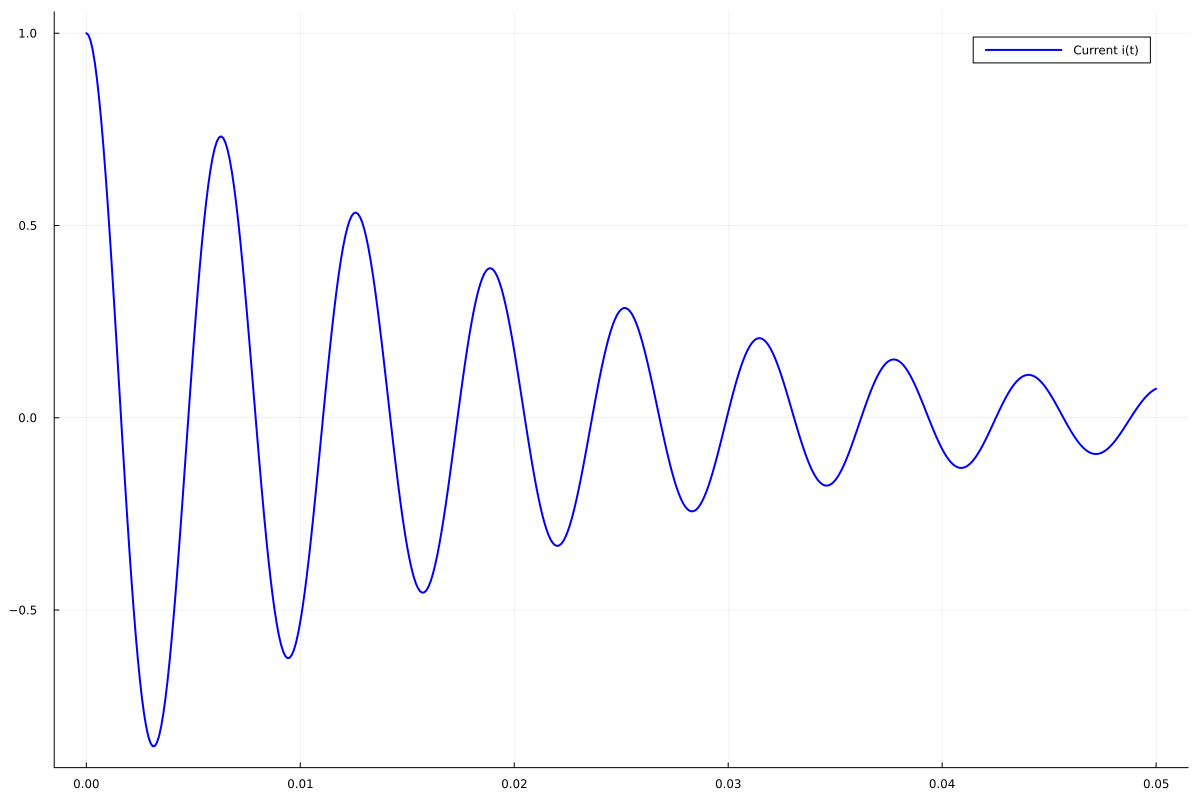

In [65]:
# Define RLC parameters
# Parameters
R = 100   # Ohms
L = 1    # Henries
C = 1e-6   # Farads
V0 = 1#220.0      # Voltage amplitude (Volts)
ω0=30#1/sqrt(L*C)

CC=(R/2)*sqrt(C/L)
ω = 2π * 100.0   # Driving frequency (radians/s) – try 1Hz

# Voltage source: sinusoidal driving force
V(t) = -V0*ω *cos.(ω * t)

# Define the system of ODEs
function rlc!(du, u, p, t)
    i, di = u
    du[1] = di
    du[2] = (1 / L) * (V(t) - R * di - i/ C)
    #du[2] = (1 / L) * (V(t) - R * i - q / C)
end

# Initial conditions: q(0) = 0, i(0) = 0
u0 = [1, 0.0]
tspan = (0.0,0.05)

# Define and solve the problem
prob = ODEProblem(rlc!, u0, tspan)
sol = solve(prob, Tsit5(), saveat=0.0001)
# Plot the results
#plot(sol.t, sol[1,:], label="Charge q(t)", xlabel="Time (s)", ylabel="Charge (C)", lw=2,color="red")
plot(sol.t, sol[1,:], label="Current i(t)", lw=2,color="blue",size=(1200,800))
#plot!(sol.t, V(sol.t), label="Voltage V(t)", lw=2,color="black")

$$V_{in}=V_R+V_C$$
$$V_R=IR$$
$$V_{in}=IR +V_C$$

$$I=C\frac{dV_C}{dt}$$


$$V_{in}=RC\frac{dV_C}{dt}+V_c$$

$$V_C(t)=V_{Ch}  + V_{Cp}$$





$$0=RC\frac{dV_C}{dt}+V_c$$



$$-\frac{V_c}{RC}=\frac{dV_C}{dt}$$

$$-\frac{dt}{RC}=\frac{dV_C}{dt}\frac{1}{V_C}$$

$$\int -\frac{dt}{RC}=\int\frac{dV_C}{dt}\frac{1}{V_C}$$


$$-\frac{t}{RC}+C=\ln(V_C)$$

$$e^{-\frac{t}{RC}+C=\ln(V_C)}$$


$$V_C=Ce^{-\frac{t}{RC}}$$


Apicando condiciones iniciales 


$$\boxed{V_C=(1-e^{-\frac{t}{RC}})}$$

$$\frac{d}{dt} \left( V_{in}=IR +V_C\right) $$


$$\frac{dV}{dt}=\frac{dI}{dt}R+\frac{dV_C}{dt}$$

In [27]:
# Define RLC parameters
# Parameters
R = 1000   # Ohms
L = 6   # Henries
C = 1e-6   # Farads
V0 = 12#220.0      # Voltage amplitude (Volts)
ω0=30#1/sqrt(L*C)

CC=(R/2)*sqrt(C/L)
ω = 2π * 60.0   # Driving frequency (radians/s) – try 1Hz

# Voltage source: sinusoidal driving force
V(t) = V0*sin.(ω * t)
dV(t)=(V(t)/abs(V(t)))*ω*V0*cos(ω*t)
ts=0.0:0.0001:0.05


# # Define the system of ODEs
# function rlc(u, p, t)
#     i=u
#     return 
# end

# # Initial conditions: q(0) = 0, i(0) = 0
# u0 = 0.0
# tspan = (0.0,0.1)

# # Define and solve the problem
# prob = ODEProblem(rlc, u0, tspan)

0.0:0.0001:0.05

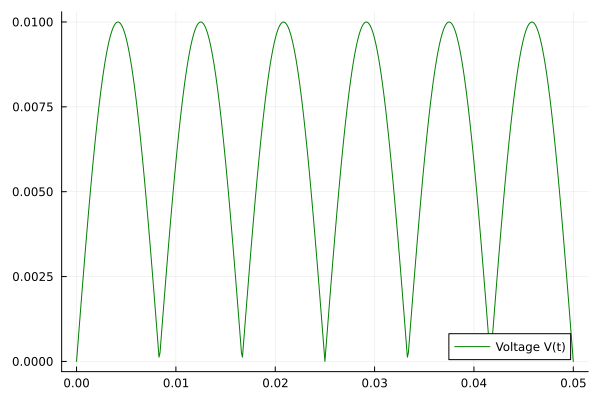

In [52]:
plot(ts,abs.(V.(ts))/(V0*100),label="Voltage V(t)",color="green")


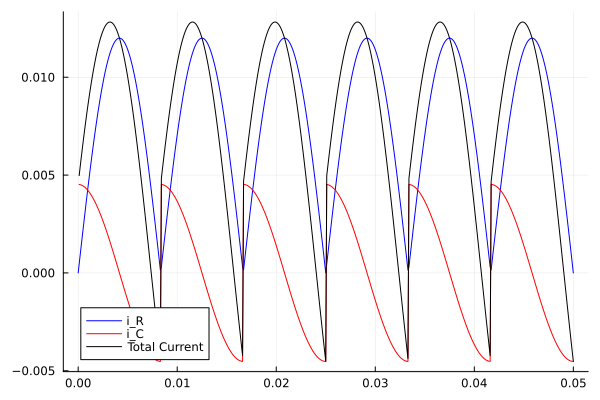

In [ ]:
iR=abs.(V.(ts))./R
iC=C*dV.(ts)
plot(ts,iR,color="blue",label="i_R")
plot!(ts,iC,label="i_C",color="red")
plot!(ts,iR.+iC,label="Total Current",color="black")


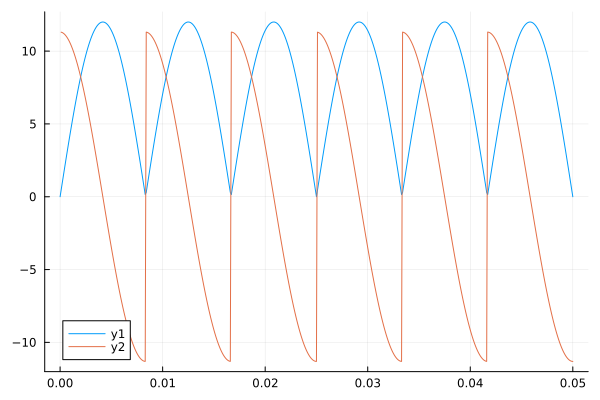

In [ ]:
plot(ts,abs.(V.(ts)))
plot!(ts,./400)

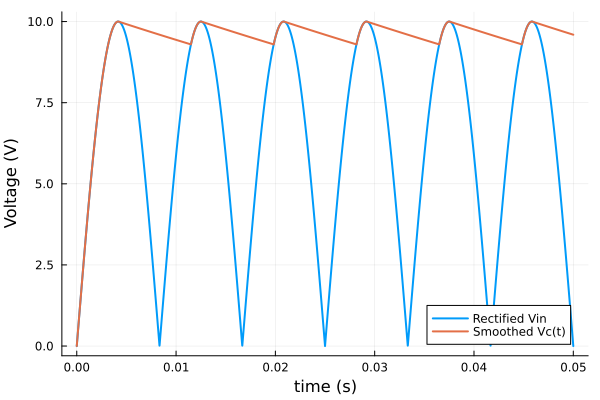

In [54]:
using Plots

# Parameters
V0 = 10.0              # amplitude
f  = 60.0              # Hz
ω  = 2π*f
R  = 10_000.0          # ohms
C  = 100e-7            # farads
dt = 1e-5              # time step
T  = 3/f               # simulate 3 cycles

t = 0:dt:T
N = length(t)
Vc = zeros(Float64, N)

# absolute value rectified input
Vin(t) = abs(V0 * sin(ω*t))

# simulate
for i in 2:N
    v_in = Vin(t[i])
    v_c  = Vc[i-1]

    if v_in > v_c
        # Diode ON (charging)
        Vc[i] = v_in
    else
        # Diode OFF (discharging)
        dVc = -(v_c)/(R*C)
        Vc[i] = v_c + dVc*dt
    end
end

# Plot
plot(t, Vin.(t), label="Rectified Vin", lw=2)
plot!(t, Vc, label="Smoothed Vc(t)", lw=2)
xlabel!("time (s)")
ylabel!("Voltage (V)")
